In [3]:
%run "////home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/simulation/simulation_prereqs/impport_packages.ipynb"    #import all necessary packages - numpy, pandas etc
%run "////home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/simulation/simulation_prereqs/simulation_class.ipynb"    #import all necessary packages - numpy, pandas etc
%run "////home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/simulation/simulation_prereqs/create_world.ipynb"

#### Setting up environmental parameters

In [7]:
#for epi


folder = Path("/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/finegrain_100_100_env/scenarios_30/epi")

epi_obj = {}

for path in folder.glob("*.pkl"):
    print(path)

    # extract dimension from filename
    match = re.search(r"dims(\d+)", path.stem)
    if match:
        dim = int(match.group(1))
        with open(path, "rb") as file:
            results_array_epi = pickle.load(file)

        epi_obj[f"epi_{dim}"] = results_array_epi

print(epi_obj.keys())

folder = Path("/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/finegrain_100_100_env/scenarios_30/onlygen")

onlygen_obj = {}

for path in folder.glob("*.pkl"):
    print(path)

    match = re.search(r"dims(\d+)", path.stem)
    if match:
        dim = int(match.group(1))
        with open(path, "rb") as file:
            results_array_gen = pickle.load(file)

        onlygen_obj[f"gen_{dim}"] = results_array_gen

print(onlygen_obj.keys())

/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/finegrain_100_100_env/scenarios_30/epi/rhos30_ms30_gens10000_dims2_mutrate0.001.pkl
/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/finegrain_100_100_env/scenarios_30/epi/rhos30_ms30_gens10000_dims5_mutrate0.001.pkl
/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/finegrain_100_100_env/scenarios_30/epi/rhos30_ms30_gens10000_dims1_mutrate0.001.pkl
/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/finegrain_100_100_env/scenarios_30/epi/rhos30_ms30_gens10000_dims10_mutrate0.001.pkl
dict_keys(['epi_2', 'epi_5', 'epi_1', 'epi_10'])
/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/finegrain_100_100_env/scenarios_30/onlygen/rhos30_ms30_gens10000_dims1_mutrate0.001_onlygen.pkl
/home/usriniva/Desktop/Phd/Epigen

In [35]:
rho_cases = 100
m_cases=  100
maxgen= 10000
popsize = 2500
                                 
initial_memory = 0
full_env_values = create_world(rho_cases, m_cases, maxgen)   # create world (input: generations, no. rhos and no. ms) 
print('shape of scenarios with nas:',full_env_values.shape)

clean_data_env = full_env_values[~np.isnan(full_env_values).any(axis=1)]

nof_scenarios = np.shape(clean_data_env)[0]

print('nof examined "worlds" or scenarios:', nof_scenarios) 

gens = np.arange(1, maxgen +1 )
print('number of generations teh simulation is run for', maxgen) 


shape of scenarios with nas: (10000, 10004)
nof examined "worlds" or scenarios: 6919
number of generations teh simulation is run for 10000


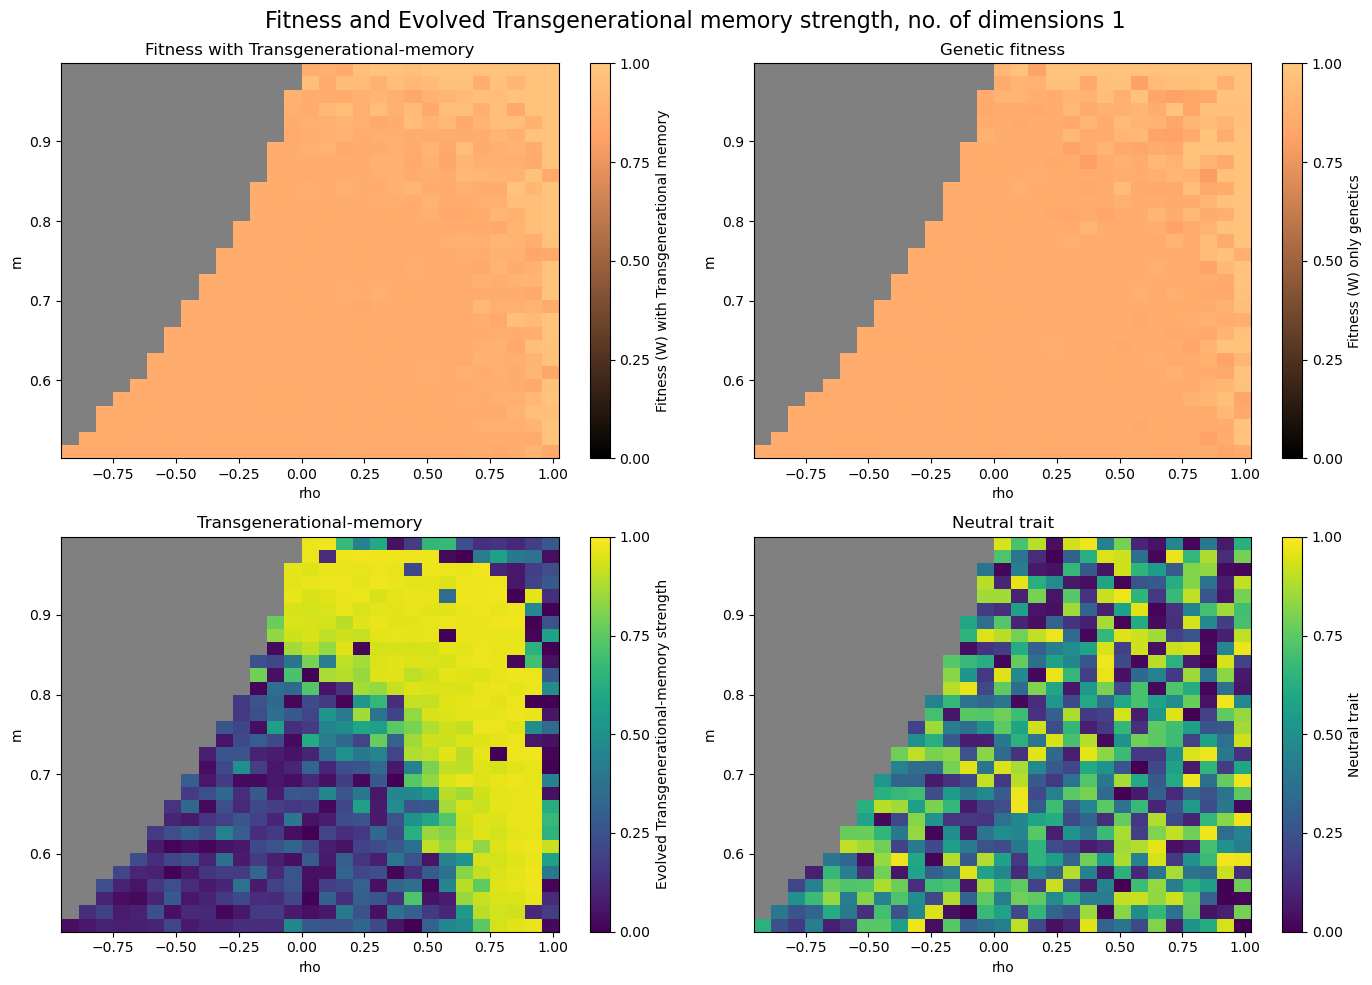

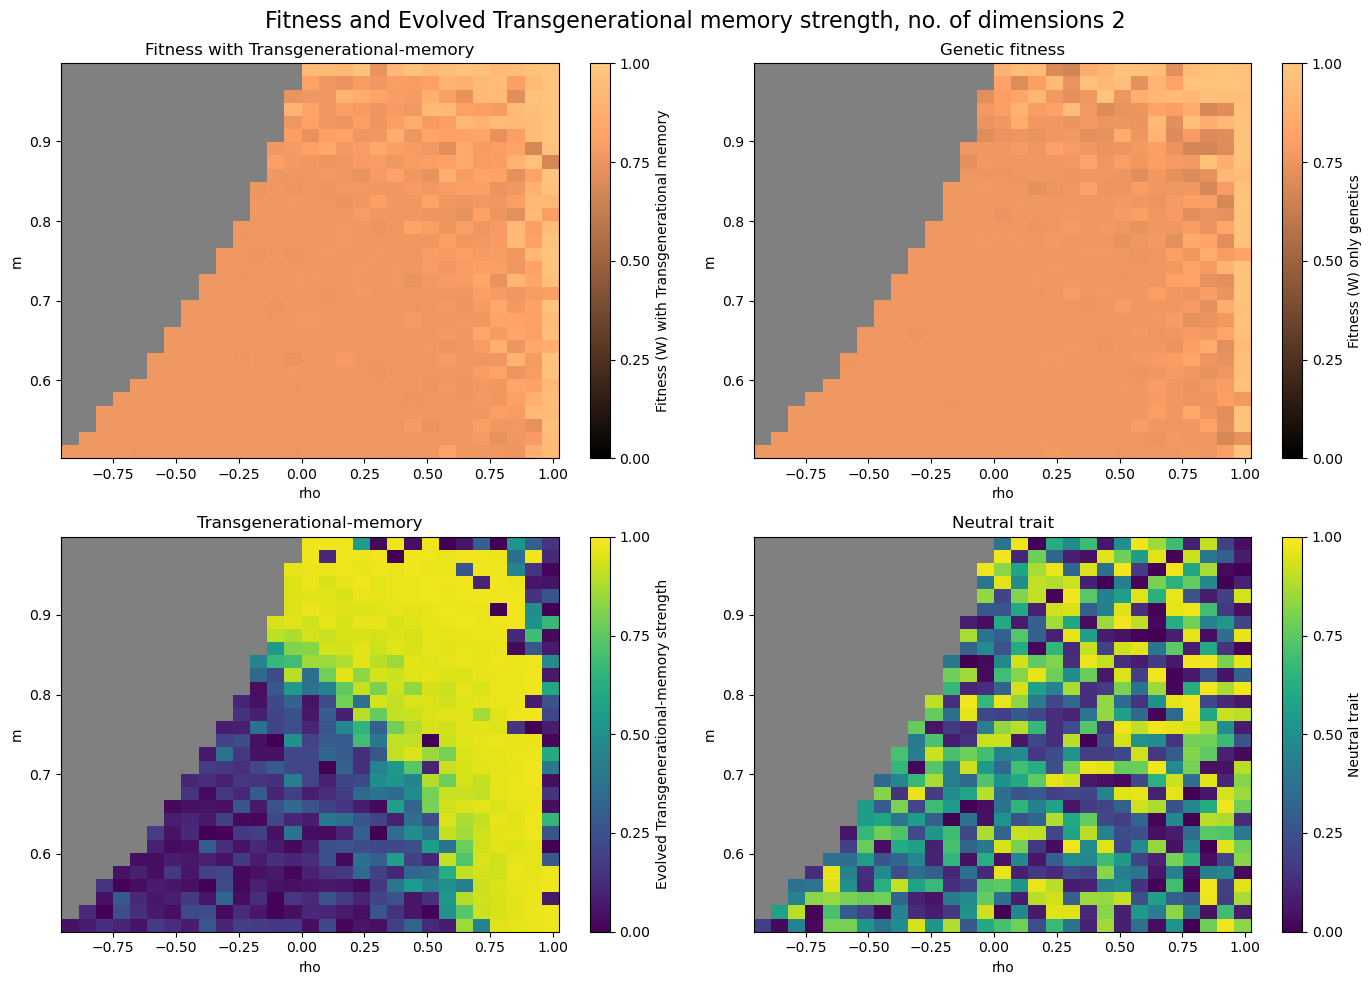

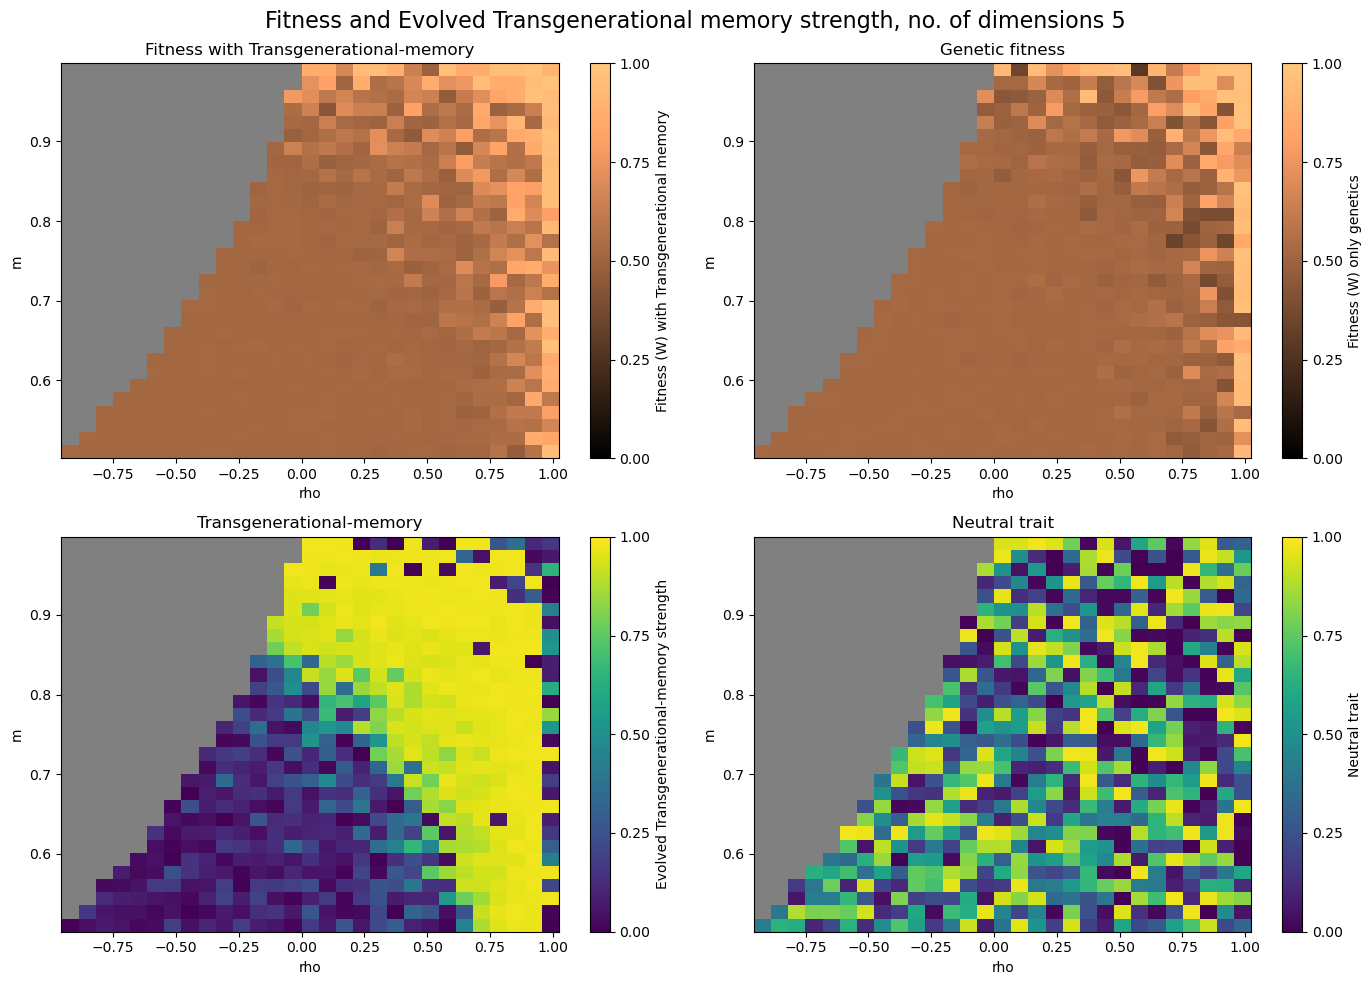

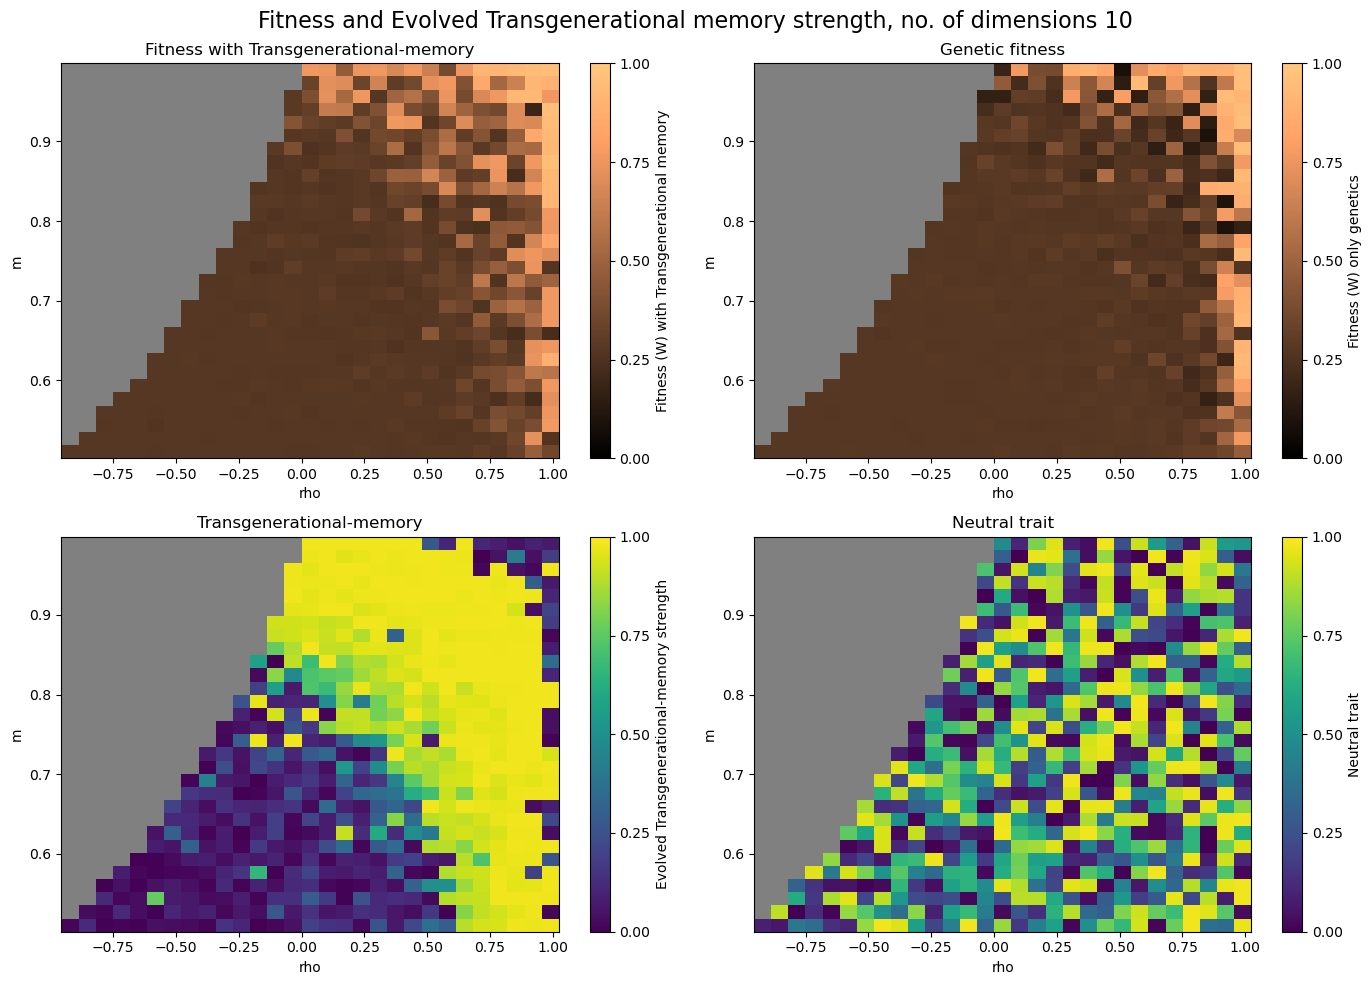

In [9]:
dims=[1,2,5,10]

for i in dims:

    concat_epi = epi_obj[f"epi_{i}"]
    concat_gen = onlygen_obj[f"gen_{i}"]   # adjust key if needed
    
    keys = list(concat_epi[0].keys())

    concatenated_results_epi = {}
    concatenated_results_gen = {}

    for k in keys:
            concatenated_results_epi[k] = np.vstack([r[k] for r in concat_epi])
            
    for k in keys:
            concatenated_results_gen[k] = np.vstack([r[k] for r in concat_gen])
            
    df_epi = pd.DataFrame({
        
    'rho': concatenated_results_epi['rho_m_alpha_beta'][:,0],
    'm': concatenated_results_epi['rho_m_alpha_beta'][:,1],
    'fitness':np.mean(concatenated_results_epi['meanw'][:,-50:], axis=1),
    'epi_mem_p': np.mean(concatenated_results_epi['meanmemory_p'][:,-50:], axis=1),
    'neutral_trait_p' : np.mean(concatenated_results_epi['meanneutral_p'][:,-50:], axis=1 ),
    
    })
    
    df_gen = pd.DataFrame({
            
        'rho': concatenated_results_gen['rho_m_alpha_beta'][:,0],
        'm': concatenated_results_gen['rho_m_alpha_beta'][:,1],
        'fitness':np.mean(concatenated_results_gen['meanw'][:,-50:], axis=1),
        })

    fig, ax = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        f"Fitness and Evolved Transgenerational memory strength, no. of dimensions {i}",
        fontsize=16
    )
    
    fig.subplots_adjust(top=0.90)

    cmap1 = plt.cm.copper.copy()
    cmap1.set_bad(color='gray')

    cmap2 = plt.cm.viridis.copy()
    cmap2.set_bad(color='gray')
    
    norm = mcolors.Normalize(vmin=0, vmax=1)
    
    # --- (0,0) fitness ---
    pivoted_fitness = df_epi.pivot_table(
        index='m', columns='rho', values='fitness'
    ).sort_index().sort_index(axis=1)

    pcm1 = ax[0,0].pcolormesh(
        pivoted_fitness.columns,
        pivoted_fitness.index,
        pivoted_fitness.values,
        cmap=cmap1, norm=norm, shading='auto'
    )
    fig.colorbar(pcm1, ax=ax[0,0],
                 label='Fitness (W) with Transgenerational memory',
                 ticks=[0,0.25,0.5,0.75,1.0])

    ax[0,0].set_title(r'Fitness with Transgenerational-memory')
    ax[0,0].set_ylabel('m')
    ax[0,0].set_xlabel('rho')

    # --- (0,1) genetic fitness ---
    pivoted_gen = df_gen.pivot_table(
        index='m', columns='rho', values='fitness'
    ).sort_index().sort_index(axis=1)

    pcm2 = ax[0,1].pcolormesh(
        pivoted_gen.columns,
        pivoted_gen.index,
        pivoted_gen.values,
        cmap=cmap1, norm=norm, shading='auto'
    )
    fig.colorbar(pcm2, ax=ax[0,1],
                 label='Fitness (W) only genetics',
                 ticks=[0,0.25,0.5,0.75,1.0])

    ax[0,1].set_title('Genetic fitness')
    ax[0,1].set_ylabel('m')
    ax[0,1].set_xlabel('rho')

    # --- (1,0) epimem ---
    pivoted_epi = df_epi.pivot_table(
        index='m', columns='rho', values='epi_mem_p'
    ).sort_index().sort_index(axis=1)

    pcm3 = ax[1,0].pcolormesh(
        pivoted_epi.columns,
        pivoted_epi.index,
        pivoted_epi.values,
        cmap=cmap2, norm=norm, shading='auto'
    )
    fig.colorbar(pcm3, ax=ax[1,0],
                 label='Evolved Transgenerational-memory strength',
                 ticks=[0,0.25,0.5,0.75,1.0])

    ax[1,0].set_title('Transgenerational-memory')
    ax[1,0].set_ylabel('m')
    ax[1,0].set_xlabel('rho')

    # --- (1,1) neutral ---
    pivoted_neutral = df_epi.pivot_table(
        index='m', columns='rho', values='neutral_trait_p'
    ).sort_index().sort_index(axis=1)

    pcm4 = ax[1,1].pcolormesh(
        pivoted_neutral.columns,
        pivoted_neutral.index,
        pivoted_neutral.values,
        cmap=cmap2, norm=norm, shading='auto'
    )
    fig.colorbar(pcm4, ax=ax[1,1],
                 label='Neutral trait',
                 ticks=[0,0.25,0.5,0.75,1.0])

    ax[1,1].set_title('Neutral trait')
    ax[1,1].set_ylabel('m')
    ax[1,1].set_xlabel('rho')

    plt.tight_layout()
    plt.show()

